In [1]:
import os
import sys
from pathlib import Path
print(os.getcwd())

ROOT_DIR = Path(os.getcwd()).parent.parent
print(ROOT_DIR)
sys.path.insert(0, str(ROOT_DIR))

/home/tinhanhnguyen/Desktop/HK7/Capstone/CAPSTONE_PROJECT/agentic_ai/test
/home/tinhanhnguyen/Desktop/HK7/Capstone/CAPSTONE_PROJECT


In [2]:
from agentic_ai.tools.clients import *
from agentic_ai.tools.schema.artifact import ImageObjectInterface, SegmentObjectInterface, VideoInterface
from agentic_ai.tools.type import *
from agentic_ai.agent import (
    code_act_prompt,
    WorkerCodeVideoAgent,
    AgentDecision,
    AgentInput,
    AgentOutput,
    AgentStream,
    AgentThinking,
    AgentStreamStructuredOutput,
    ToolCallResult,
    ToolCall
)
from agentic_ai.worker.executor import build_worker_executor

In [3]:
# CONSTANT
MILVUS_HOST = "localhost"
MILVUS_PORT = 19530
MILVUS_URI = f"http://{MILVUS_HOST}:{MILVUS_PORT}"

IMAGE_COLLECTION_NAME = "image_milvus"
IMAGE_VISUAL_PARAM = {
    "type_config": "dense",
    "dimension": 512,
    "metric_type": "COSINE",
    "index_type": "HNSW",
    "description": "Image embeddings for video frames",
    "index_params": {"M": 64, "efConstruction": 100},
}
IMAGE_CAPTION_DENSE_PARAM = {
    "type_config": "dense",
    "dimension": 768,
    "metric_type": "COSINE",
    "index_type": "HNSW",
    "description": "Text embeddings for image captions",
    "index_params": {"M": 64, "efConstruction": 100},
}
IMAGE_CAPTION_SPARSE_PARAM = {
    "type_config": "sparse",
    "dimension": 1000000,  # ignored at runtime
    "metric_type": "BM25",
    "index_type": "SPARSE_INVERTED_INDEX",
    "description": "BM25 sparse index for image captions",
    "index_params": {"inverted_index_algo": "DAAT_MAXSCORE"},
}
IMAGE_VISUAL_FIELD = "visual_embedding_field"
IMAGE_CAPTION_FIELD = "caption_embedding_field"
IMAGE_SPARSE_FIELD = "caption_sparse_embedding_field"


SEGMENT_CAPTION_COLLECTION_NAME = "segment_milvus"
SEGMENT_CAPTION_DENSE_PARAM = {
    "type_config": "dense",
    "dimension": 768,
    "metric_type": "COSINE",
    "index_type": "HNSW",
    "description": "Text embeddings for segment captions",
    "index_params": {"M": 64, "efConstruction": 100},
}
SEGMENT_CAPTION_SPARSE_PARAM = {
    "type_config": "sparse",
    "dimension": 1000000,  # ignored at runtime
    "metric_type": "BM25",
    "index_type": "SPARSE_INVERTED_INDEX",
    "description": "BM25 sparse index for segment captions",
    "index_params": {"inverted_index_algo": "DAAT_MAXSCORE"},
}

SEGMENT_DENSE_FIELD = "caption_embedding_field"
SEGMENT_SPARSE_FIELD = "caption_sparse_embedding_field"



In [4]:
image_milvus_client = ImageMilvusClient(
    uri=MILVUS_URI,
    collection_name=IMAGE_COLLECTION_NAME,
    visual_param=IMAGE_VISUAL_PARAM,
    caption_param=IMAGE_CAPTION_DENSE_PARAM,
    sparse_param=IMAGE_CAPTION_SPARSE_PARAM,
    visual_ann_field=IMAGE_VISUAL_FIELD,
    caption_ann_field=IMAGE_CAPTION_FIELD,
    sparse_field=IMAGE_SPARSE_FIELD,
)

segment_caption_client = SegmentCaptionImageMilvusClient(
    uri=MILVUS_URI,
    collection_name=SEGMENT_CAPTION_COLLECTION_NAME,
    dense_param=SEGMENT_CAPTION_DENSE_PARAM,
    sparse_param=SEGMENT_CAPTION_SPARSE_PARAM,
    dense_field=SEGMENT_DENSE_FIELD,
    sparse_field=SEGMENT_SPARSE_FIELD,
)

await image_milvus_client.connect()
await segment_caption_client.connect()

In [5]:
image_emebedding_settings = ImageEmbeddingSettings(
    model_name='open_clip',
    device='cuda',
    batch_size=32
)
text_emebedding_settings = TextEmbeddingSettings(
    model_name='mmbert',
    device='cuda',
    batch_size=32
)

img_txt_client = ImageEmbeddingClient(base_url='http://localhost:8003')
txt_client = TextEmbeddingClient(base_url='http://localhost:8005')


external_client = ExternalEncodeClient(img_text_client=img_txt_client, img_text_settings=image_emebedding_settings, txt_settings=text_emebedding_settings, txt_client=txt_client)

await external_client.connect()

2025-11-05 18:19:44.198 | INFO     | agentic_ai.tools.clients.external.base:load_model:126 - service-image-embedding_model_loaded
2025-11-05 18:19:44.201 | INFO     | agentic_ai.tools.clients.external.base:load_model:126 - service-text-embedding_model_loaded


In [6]:
MINIO_HOST = "localhost"       # use localhost when running locally
MINIO_PORT = 9000
MINIO_USER = "minioadmin"
MINIO_PASSWORD = "minioadmin"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "minioadmin"
MINIO_SECURE = False  
MINIO_ENDPOINT = f"{MINIO_HOST}:{MINIO_PORT}"

storage_client = StorageClient(
    host=MINIO_HOST,
    port=MINIO_PORT,#type:ignore
    access_key=MINIO_ACCESS_KEY,
    secret_key=MINIO_SECRET_KEY,
    secure=MINIO_SECURE,
)

storage_client._ensure_bucket('anonymous')

In [7]:
from sqlalchemy import text

POSTGRE_USER = "prefect"
POSTGRE_PASSWORD = "prefect"
POSTGRE_HOST = "localhost"       # use localhost for local setup
POSTGRE_PORT = 5432
POSTGRE_DB = "prefect"

POSTGRE_DATABASE_URL = (
    f"postgresql+asyncpg://{POSTGRE_USER}:{POSTGRE_PASSWORD}"
    f"@{POSTGRE_HOST}:{POSTGRE_PORT}/{POSTGRE_DB}"
)
postgres_client = PostgresClient(
    database_url=POSTGRE_DATABASE_URL
)
async with postgres_client.get_session() as session:
    result = await session.execute(text("SELECT version();"))
    version = result.scalar_one()
    print(f"🗄️ PostgreSQL connection successful.\n   Version: {version}")

🗄️ PostgreSQL connection successful.
   Version: PostgreSQL 14.19 (Debian 14.19-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit


In [8]:
from google.genai import types
from llama_index.llms.google_genai import GoogleGenAI
from dotenv import load_dotenv
load_dotenv()


generation_config = types.GenerateContentConfig(
    temperature=0.7,
    thinking_config=types.ThinkingConfig(thinking_budget=1024, include_thoughts=True)
)

llm = GoogleGenAI(
    model='gemini-2.5-flash',
    generation_config=generation_config   
)

tool_factory = ToolFactory(
    image_milvus_client=image_milvus_client,
    segment_milvus_client=segment_caption_client,
    postgres_client=postgres_client,
    minio_client=storage_client,
    external_client=external_client,
    llm_as_tools=llm
)

In [9]:
tools = tool_factory.get_all_tools()

get_video_from_segment
get_video_from_image
get_asr_from_video
get_all_segment_info_from_video_interface
get_segments
get_images
extract_frames_by_time_window
extract_frame_time
frame_to_timecode
timecode_to_frame
from_index_to_time
from_range_index_to_range_time
from_time_to_index
from_range_time_to_range_index
read_image
read_segment
get_related_asr_from_image
get_related_asr_from_segment
get_images_from_visual_query
get_images_from_caption_query
get_segments_from_event_query
get_images_from_multimodal_query
find_similar_images_from_image
enhance_visual_query
enhance_textual_query
caption_new_image


In [10]:
USER = "anonymous"
LIST_VIDEO_IDS = ["video1_111", "video2_222"]

In [11]:
SYSTEM_PROMPT = """
You are a professional in Video Deep Search. Given a list of tools, you are able to dewordcide whether to use them directly or create an executable environment. The point is to fullfil the user's retrieval demand. You may read the images once retrieve for ensurance.
"""

In [12]:
get_all_functools = tool_factory.get_all_tools_functool(
    user_id=USER,
    list_video_id=LIST_VIDEO_IDS,
    agent_bucket='agent_test',
    agent_object_folder='agent_worker_small'
)

get_all_tools_normal = tool_factory.get_all_tools_normal(
    user_id=USER,
    list_video_id=LIST_VIDEO_IDS,
    agent_bucket='agent_test',
    agent_object_folder='agent_worker_small'
)

In [13]:
test_tools = [
    'get_images_from_visual_query',
    'get_segments_from_event_query',
    'read_image',
    'read_segment',
    'enhance_visual_query',
    'enhance_textual_query',
    'get_segments',
    'get_images',
    'frame_to_timecode',
    'timecode_to_frame',
    'from_index_to_time',
    'get_related_asr_from_image',
    'get_related_asr_from_segment',
    'extract_frame_time',
]

In [14]:
get_test_tools_func = list(
    filter(lambda x: x[0] in test_tools, get_all_functools.items())
)
get_test_tools_normal = dict(list(
    filter(lambda x: x[0] in test_tools, get_all_tools_normal.items())
))

In [15]:
globals_dependency = tool_factory.dependency_map
globals_dependency.update(
    {
        'ImageObjectInterface': ImageObjectInterface,
        'SegmentObjectInterface': SegmentObjectInterface,
        'VideoInterface': VideoInterface
    }
)

env_fn = build_worker_executor(
    tools_bindings=get_all_tools_normal,
    extra_globals=globals_dependency
)

In [16]:
get_test_tools_func

[('get_segments',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f2bf290>),
 ('get_images',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f5ef800>),
 ('extract_frame_time',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f27f020>),
 ('frame_to_timecode',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f27ec30>),
 ('timecode_to_frame',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f35ee40>),
 ('from_index_to_time',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f2bf3e0>),
 ('read_image',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f27e240>),
 ('read_segment',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f27fbc0>),
 ('get_related_asr_from_image',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f3436e0>),
 ('get_related_asr_from_segment',
  <llama_index.core.tools.function_tool.FunctionTool at 0x73226f2bfa40>),
 ('get_images_from_visual_query'

In [17]:
worker_agent = WorkerCodeVideoAgent(
    execution_history_key="agent",
    code_execute_fn=env_fn,
    code_act_system_prompt=code_act_prompt,
    name='WorkerCodeVideoAgent',
    description="Agent that can utilizing tools for Deep Video Search",
    system_prompt=SYSTEM_PROMPT,
    tools=[tool[1] for tool in get_test_tools_func],
    llm=llm,
    streaming=True,
    verbose=True,    
)

# Test

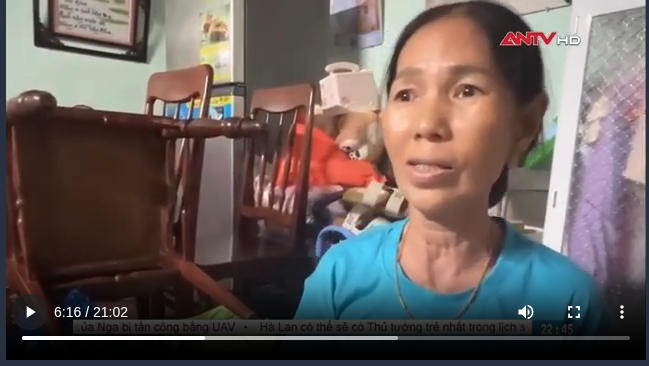

In [ ]:
user_demand = """
Tôi muốn tìm một hình ảnh, Trong hình là một người phụ nữ trung niên đang ngồi trong căn phòng có nhiều đồ đạc sinh hoạt. Bà mặc áo màu xanh dương, tóc buộc gọn ra sau. Bạn hãy sử dụng code mode, tạo ra một số biến thể của câu trên, và tìm ra bức ảnh
"""

In [19]:
from llama_index.core.workflow import Context
ctx = Context(worker_agent)

In [20]:
import asyncio
import json
import datetime
from pprint import pformat
from pathlib import Path
from rich.console import Console
from rich.markdown import Markdown
from rich.panel import Panel
from rich.text import Text
from rich.table import Table
import aiofiles

console = Console()

async def run_agent_verbose_dual(
    agent,
    ctx,
    query: str,
):
    """
    Run an agent with live rich console display and dual-stream logging.
    """

    handler = agent.run(user_msg=query, ctx=ctx)
    Path("logs").mkdir(parents=True, exist_ok=True)

    console.rule(f"[bold blue]🧑‍💻 User Query[/bold blue]")
    console.print(Markdown(f"**{query}**"))


    async for event in handler.stream_events():
        event_type = type(event).__name__
        data = event.__dict__

        if event_type == "AgentSetup":
            console.rule("[bold cyan]⚙️ Agent Setup[/bold cyan]")

        elif event_type == "AgentInput":
            console.print(Panel(f"{pformat(data)}", title="Agent Input", border_style="bright_cyan"))

        elif event_type == "AgentStream":
            if event.thinking_delta:
                console.print(Text(event.thinking_delta, style="dim italic"), end="")
            elif event.delta:
                console.print(Text(event.delta, style="bold white"), end="")

        elif event_type == "AgentStreamStructuredOutput":
            console.rule("[bold magenta]🧱 Structured Output[/bold magenta]")
            console.print_json(json.dumps(event.output, indent=4))

        elif event_type == "ToolCall":
            console.rule("[bold yellow]🛠️ Tool Call[/bold yellow]")
            table = Table(title=event.tool_name)
            table.add_column("Argument", style="cyan")
            table.add_column("Value", style="white")
            for k, v in event.tool_kwargs.items():
                table.add_row(k, str(v))
            console.print(table)

        elif event_type == "ToolCallResult":
            console.rule("[bold green]📦 Tool Result[/bold green]")
            console.print_json(json.dumps(event.tool_output, default=str))

        elif event_type == "AgentDecision":
            console.rule("[bold blue]🧭 Agent Decision[/bold blue]")
            console.print(Panel(pformat(data), border_style="blue"))

        elif event_type == "AgentOutput":
            console.rule("[bold green]✅ Final Output[/bold green]")
            console.print(Markdown(event.response.content))


    console.rule("[bold bright_green]🏁 Agent Run Complete[/bold bright_green]")
    return await handler

In [21]:
response = await run_agent_verbose_dual(
    worker_agent, ctx, user_demand
)

───────────────────────────────────────────────── 🧑‍💻 User Query ─────────────────────────────────────────────────

** Tôi muốn tìm một hình ảnh, Trong hình là một người phụ nữ trung niên đang ngồi trong căn phòng có nhiều đồ đạc  
sinh hoạt. Bà mặc áo màu xanh dương, tóc buộc gọn ra sau. Bạn hãy sử dụng code mode, tạo ra một số biến thể của câu
trên, và tìm ra bức ảnh **

╭────────────────────────────────────────────────── Agent Input ──────────────────────────────────────────────────╮
│ {'current_agent_name': 'WorkerCodeVideoAgent',                                                                  │
│  'input': [ChatMessage(role=<MessageRole.SYSTEM: 'system'>, additional_kwargs={},                               │
│ blocks=[TextBlock(block_type='text', text="\nYou are a professional in Video Deep Search. Given a list of       │
│ tools, you are able to dewordcide whether to use them directly or create an executable environment. The point   │
│ is to fullfil the user's retrieval demand. You may read the images once retrieve for ensurance.\n")]),          │
│            ChatMessage(role=<MessageRole.USER: 'user'>, additional_kwargs={},                                   │
│ blocks=[TextBlock(block_type='text', text='\nTôi muốn tìm một hình ảnh, Trong hình là một người phụ nữ trung    │
│ niên đang ngồi trong căn phòng có nhiều đồ đạc sinh hoạt. Bà mặc áo màu xanh dương, tóc buộc gọn ra sau. Bạn    │
│ hãy sử dụng code mode, tạo ra một số biến thể của câu trên, và tìm ra bức ảnh\n')]),                            │
│            ChatMessage(role=<MessageRole.USER: 'user'>, additional_kwargs={},                                   │
│ blocks=[TextBlock(block_type='text', text='\n    You must pick the execution mode that will get the user to a   │
│ reliable answer with the least risk.\n\n    ## Policy Checklist\n    1. Read the conversation and summarise the │
│ user goal in your head.\n    2. Inspect the available tools before deciding.\n    3. Use the rubric below to    │
│ choose between direct `tools` usage or authoring coordinating `code`.\n\n    ### OPTION 1 — tools (default for  │
│ quick wins)\n    Select `tools` when the request is satisfied by:\n    - A single tool call or a very short     │
│ chain with no branching.\n    - Pure retrieval, lookup, or metadata enrichment.\n    - Lightweight filtering    │
│ that the tool already supports via parameters.\n    - Cases where the user explicitly asks you to call a        │
│ specific tool once.\n\n    ### OPTION 2 — code (medium & complex orchestration)\n    Select `code` when you     │
│ need to:\n    - Combine results from multiple tools (fan-out/fan-in) or loop over items.\n    - Execute         │
│ conditional logic, sorting, ranking, or aggregation beyond built-in tool parameters.\n    - Cache intermediate  │
│ results, compare alternatives, or post-process responses.\n    - Validate tool outputs, handle fallbacks, or    │
│ call tools with adaptive parameters.\n    - Prepare data for follow-up reasoning or final answering.\n\n        │
│ Always justify your choice referencing the plan (e.g., "need to fan out across visual + caption tools, then     │
│ merge").\n\n    **Available tools:**\n    def get_segments(current_segment:                                     │
│ agentic_ai.tools.schema.artifact.SegmentObjectInterface, hop: Annotated, include_within_range: bool,            │
│ forward_or_backward: Literal[\'forward\', \'backward\']) ->                                                     │
│ agentic_ai.tools.schema.artifact.SegmentObjectInterface | list:\n  """\nGiven a current segment, return the     │
│ next segments, based on the hop size\nArgs:\n    current_segment: \n    hop (int): the hop size\n               │
│ include_within_range (bool): If True, then all the range within hop is included, else just return the           │
│ destination segment\n  """\n\n  ...\n\n\ndef get_images(image:                                                  │
│ agentic_ai.tools.schema.artifact.ImageObjectInterface, hop: int, include_within_range: bool,                    │
│ forward_or_backward: Literal[\'forward\', \'backward\']) ->                                                     │
│ agentic_ai.tools.schema.artifact.ImageObjectInterface | list:\n  ...\n\n\ndef                                   │
│ extract_frame_time(video_interface: agentic_ai.tools.s

[ChatMessage(role=<MessageRole.SYSTEM: 'system'>, additional_kwargs={}, blocks=[TextBlock(block_type='text', text='You are a a professional in Video Deep Search. Given a list of tools description, and the user\'s demand, you are able to write an executable complex Python code to satisfy the given problems.\n\nRules:\n- Start by sketching a short execution plan (as comments) that explains which tools you will call and why.\n- Python code must be wrapped in <execute>...</execute> tags and should deliver a tangible step toward the final answer.\n- Use the provided tools liberally: coordinate multiple calls, branch when necessary, and merge results programmatically.\n- Print any intermediate values that you will need for reasoning or final answers so they appear in the execution logs.\n- Add lightweight validations or retries for empty/failed tool responses before moving on.\n- If previous code execution already contains the answer, prefer returning a natural language summary instead of re

──────────────────────────────────────────────── 🧭 Agent Decision ────────────────────────────────────────────────

...

."

Hình ảnh này khớp với tất cả các tiêu chí bạn đưa ra: một người phụ nữ trung niên, mặc áo màu xanh dương, tóc buộc 
gọn gàng, và đang ngồi trong một căn phòng có nhiều đồ đạc sinh hoạt

.

───────────────────────────────────────────────── ✅ Final Output ─────────────────────────────────────────────────

Dựa trên kết quả tìm kiếm, tôi đã tìm thấy một hình ảnh phù hợp nhất với mô tả của bạn.                            

Hình ảnh này (từ video1_111, frame_index=11105) mô tả: "Một người phụ nữ trung niên đang được phỏng vấn hoặc đang  
phát biểu bên trong một ngôi nhà có phần bừa bộn. Người phụ nữ có làn da ngăm, tóc đen búi thấp gọn gàng và đang   
mặc một chiếc áo thun màu xanh da trời sáng. Bối cảnh phía sau người phụ nữ khá lộn xộn, gợi lên hình ảnh một không
gian sinh hoạt cá nhân hoặc gia đình có nhiều đồ đạc chất đống."                                                   

Hình ảnh này khớp với tất cả các tiêu chí bạn đưa ra: một người phụ nữ trung niên, mặc áo màu xanh dương, tóc buộc 
gọn gàng, và đang ngồi trong một căn phòng có nhiều đồ đạc sinh hoạt.

────────────────────────────────────────────── 🏁 Agent Run Complete ──────────────────────────────────────────────

In [ ]:

# from google.genai import types
# from llama_index.llms.google_genai import GoogleGenAI
# from dotenv import load_dotenv
# from pydantic import BaseModel
# from llama_index.core.base.llms.types import ChatMessage
# from pprint import pprint
# load_dotenv()


# llm = GoogleGenAI(
#     model='gemini-2.5-flash',
# )


# class Hello(BaseModel):
#     hello_response: str

# input_msg = ChatMessage(role="user", content="Hello, give me a long poem on dinosaur")
# sllm = llm.as_structured_llm(Hello)
# stream_output = await sllm.astream_chat([input_msg])

# async for partial_output in stream_output:
#     pprint(partial_output.raw.model_dump_json())
#     restaurant_obj = partial_output.raw